# R5 — Resultados del canal de sentimiento rediseñado (7 empresas BVL)

Corrida definitiva del 2026-09-01: **gemma3:12b** (Ollama, servidor con GPU), prompt **v2.1**, temperatura 0 y salida JSON forzada. El modelo NO asigna un puntaje de sentimiento: clasifica el **tipo de evento** en una taxonomía ex-ante de 15 categorías y solo da polaridad cuando la categoría es relevante (magnitud > 0). Las categorías de magnitud cero son el filtro de relevancia. Un prefiltro de expresiones regulares descarta antes del LLM las crónicas del índice y los patrocinios.

Especificación: `docs/taxonomia_eventos_R5.txt`. Validación contra 550 titulares anotados por el autor: `docs/auditoria_anotacion_humana_R5.txt`. Decisiones D11-D19: `docs/decisiones_pendientes_OE1.txt`.

Insumos: `data/interim/sentiment_articulos_<TICKER>.parquet` (un registro por titular) y el panel unificado `data/processed/dataset_unificado.parquet`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from src.sentiment.taxonomia import TAXONOMIA, ERROR

DATA_INTERIM = pathlib.Path('../data/interim')
DATA_PROCESSED = pathlib.Path('../data/processed')

TICKERS = ['CREDITC1', 'ALICORC1', 'INRETC1', 'CPACASC1', 'FERREYC1', 'LUSURC1', 'MINSURI1']
NOMBRES = {'CREDITC1': 'BCP', 'ALICORC1': 'Alicorp', 'INRETC1': 'InRetail',
           'CPACASC1': 'Pacasmayo', 'FERREYC1': 'Ferreycorp', 'LUSURC1': 'Luz del Sur',
           'MINSURI1': 'Minsur'}
COLORES = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
COLOR_MAP = dict(zip(TICKERS, COLORES))
COLOR_POL = {'positivo': '#2a9d5c', 'neutral': '#9aa5b1', 'negativo': '#d1495b'}

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 11})

art = pd.concat([pd.read_parquet(DATA_INTERIM / f'sentiment_articulos_{t}.parquet')
                 for t in TICKERS], ignore_index=True)
art['fecha'] = pd.to_datetime(art['publish_date'])
# `relevante` y la bandera de titular vienen como enteros 0/1: como máscara hay que
# castearlos (indexar con un entero selecciona columnas; `~` sobre un entero es bitwise).
art['relevante'] = art['relevante'].astype(bool)
art['titular_nombra_empresa'] = art['titular_nombra_empresa'].astype(bool)
panel = pd.read_parquet(DATA_PROCESSED / 'dataset_unificado.parquet')
print(f'Titulares en el corpus: {len(art):,}')
print(f'Con error de parseo del LLM: {(art.categoria == ERROR).sum()}')
print(f'Clasificados: {(art.categoria != ERROR).sum():,}  |  eventos relevantes: {int(art.relevante.sum()):,}')

Titulares en el corpus: 19,528
Con error de parseo del LLM: 15
Clasificados: 19,513  |  eventos relevantes: 2,237


## 1. Resumen por activo

In [2]:
ok = art[art.categoria != ERROR]
res = (ok.groupby('ticker')
         .agg(titulares=('id', 'size'),
              por_prefiltro=('origen', lambda s: (s == 'prefiltro').sum()),
              por_llm=('origen', lambda s: (s == 'llm').sum()),
              nombra_empresa=('titular_nombra_empresa', 'sum'),
              relevantes=('relevante', 'sum'))
         .reindex(TICKERS))
res['% relevantes'] = (res['relevantes'] / res['titulares'] * 100).round(1)
res['% nombra empresa'] = (res['nombra_empresa'] / res['titulares'] * 100).round(1)
anios = (panel.date.max() - panel.date.min()).days / 365.25
res['eventos/año'] = (res['relevantes'] / anios).round(1)
res.loc['TOTAL'] = res.sum(numeric_only=True)
res.loc['TOTAL', ['% relevantes', '% nombra empresa', 'eventos/año']] = [
    round(res.loc['TOTAL', 'relevantes'] / res.loc['TOTAL', 'titulares'] * 100, 1),
    round(res.loc['TOTAL', 'nombra_empresa'] / res.loc['TOTAL', 'titulares'] * 100, 1),
    round(res.loc['TOTAL', 'relevantes'] / anios, 1)]
res.astype({c: int for c in ['titulares', 'por_prefiltro', 'por_llm', 'nombra_empresa', 'relevantes']})

,titulares,por_prefiltro,por_llm,nombra_empresa,relevantes,% relevantes,% nombra empresa,eventos/año
ticker,,,,,,,,
CREDITC1,10025,563,9462,1970,889,8.9,19.7,63.5
ALICORC1,1719,426,1293,265,258,15.0,15.4,18.4
INRETC1,3199,219,2980,445,499,15.6,13.9,35.7
CPACASC1,843,329,514,87,97,11.5,10.3,6.9
FERREYC1,1752,322,1430,129,123,7.0,7.4,8.8
LUSURC1,1055,135,920,122,217,20.6,11.6,15.5
MINSURI1,920,257,663,134,154,16.7,14.6,11.0
TOTAL,19513,2251,17262,3152,2237,11.5,16.2,159.9


## 2. Distribución de categorías de la taxonomía por activo (Figura 11)

Cada barra suma el 100% de los titulares clasificados del activo. Los tonos cálidos son categorías **relevantes** (magnitud > 0: alta, media o baja); los grises son las categorías de **magnitud cero**, que funcionan como filtro de relevancia (incluye lo descartado por el prefiltro, que se etiqueta como `indice_bursatil` o `patrocinio_rse`). El "% relev." es el del MODELO, que sobre-declara relevancia (precisión medida 59.3% contra la anotación del autor; la relevancia poblacional estimada es 7.2% ±2.8 pp). La gran mayoría del corpus es ruido: crónicas del índice, menciones de pasada y noticias sectoriales.

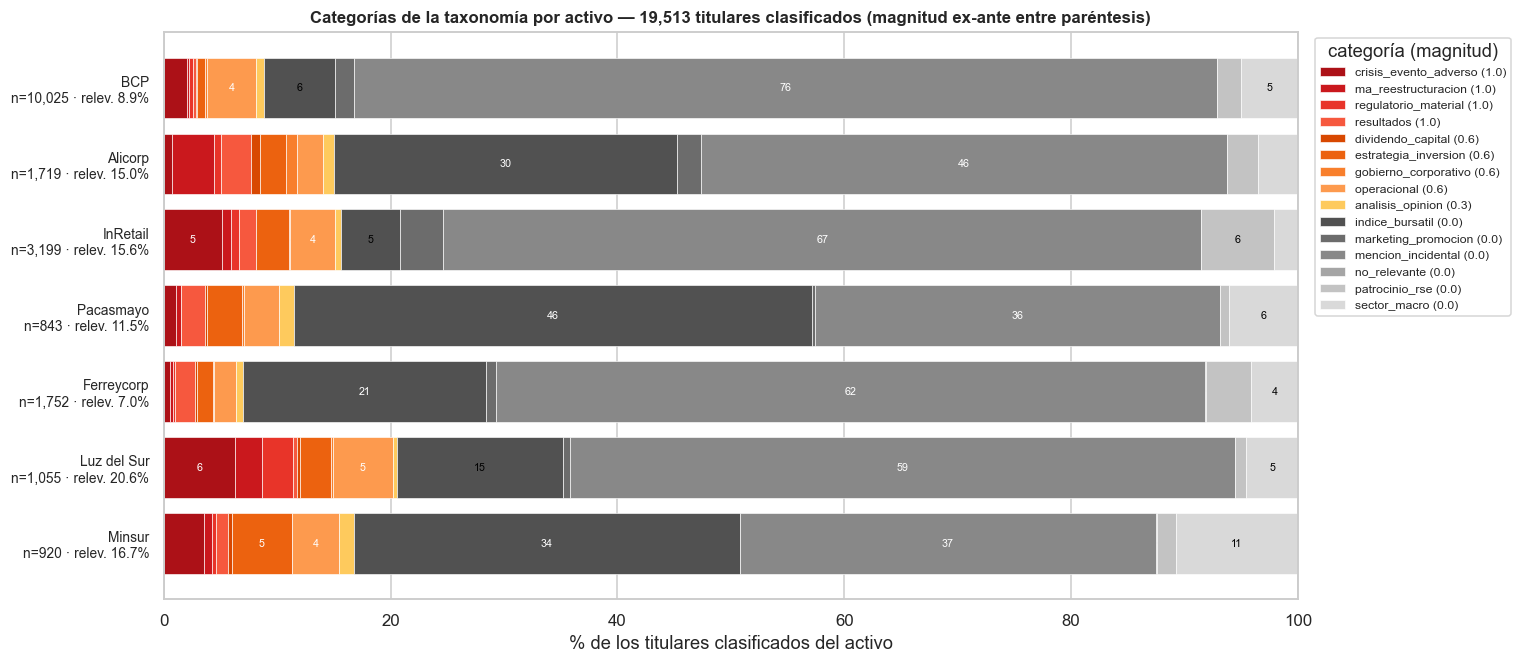

ticker,magnitud,CREDITC1,ALICORC1,INRETC1,CPACASC1,FERREYC1,LUSURC1,MINSURI1,TOTAL
categoria,,,,,,,,,
crisis_evento_adverso,1.0,208,13,163,9,9,66,33,501
ma_reestructuracion,1.0,19,63,28,4,6,25,6,151
regulatorio_material,1.0,32,10,22,0,2,29,3,98
resultados,1.0,28,46,46,18,31,4,10,183
dividendo_capital,0.6,6,14,1,1,3,3,3,31
estrategia_inversion,0.6,69,39,93,26,25,29,49,330
gobierno_corporativo,0.6,22,17,2,2,2,1,0,46
operacional,0.6,431,39,129,26,33,56,38,752
analisis_opinion,0.3,74,17,15,11,12,4,12,145


In [3]:
TRAMO = {c: ('alto' if m == 1.0 else 'medio' if m == 0.6 else 'bajo' if m == 0.3 else 'cero')
         for c, (m, _) in TAXONOMIA.items()}
ORDEN = sorted(TAXONOMIA, key=lambda c: (-TAXONOMIA[c][0], c))
PALETA = {'alto': plt.cm.Reds(np.linspace(0.85, 0.55, 4)),
          'medio': plt.cm.Oranges(np.linspace(0.75, 0.45, 4)),
          'bajo': [plt.cm.YlOrBr(0.35)],
          'cero': plt.cm.Greys(np.linspace(0.75, 0.25, 6))}
colores_cat, usados = {}, {k: 0 for k in PALETA}
for c in ORDEN:
    tr = TRAMO[c]
    colores_cat[c] = PALETA[tr][usados[tr]]
    usados[tr] += 1

dist = pd.crosstab(ok['ticker'], ok['categoria'], normalize='index').reindex(TICKERS)[ORDEN] * 100
n_por = ok['ticker'].value_counts()

fig, ax = plt.subplots(figsize=(14, 6.2))
izq = np.zeros(len(TICKERS))
for c in ORDEN:
    v = dist[c].values
    etiqueta = f'{c} ({TAXONOMIA[c][0]:.1f})'
    ax.barh(range(len(TICKERS)), v, left=izq, color=colores_cat[c], label=etiqueta,
            edgecolor='white', linewidth=0.4)
    for i, (x0, w) in enumerate(zip(izq, v)):
        if w >= 4:
            ax.text(x0 + w / 2, i, f'{w:.0f}', ha='center', va='center', fontsize=7,
                    color='white' if TRAMO[c] in ('alto', 'medio') or w > 15 else 'black')
    izq += v
rel = ok.groupby('ticker')['relevante'].mean().reindex(TICKERS) * 100
ax.set_yticks(range(len(TICKERS)))
ax.set_yticklabels([f'{NOMBRES[t]}\nn={n_por[t]:,} · relev. {rel[t]:.1f}%' for t in TICKERS], fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel('% de los titulares clasificados del activo')
ax.set_title(f'Categorías de la taxonomía por activo — {len(ok):,} titulares clasificados '
             f'(magnitud ex-ante entre paréntesis)', fontweight='bold')
ax.legend(ncol=1, fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left', title='categoría (magnitud)')
plt.tight_layout()
plt.show()

tabla = pd.crosstab(ok['categoria'], ok['ticker']).reindex(index=ORDEN, columns=TICKERS).fillna(0).astype(int)
tabla['TOTAL'] = tabla.sum(axis=1)
tabla.insert(0, 'magnitud', [TAXONOMIA[c][0] for c in tabla.index])
tabla

## 3. Eventos relevantes por año, activo y polaridad (Figura 12)

Eventos = titulares de categoría relevante (magnitud > 0), fechados por su publicación. La polaridad la emite el modelo solo para estas categorías (positivo / neutral / negativo). La escala vertical es común a los siete activos para que se vea la heterogeneidad de cobertura (BCP frente a Pacasmayo o Ferreycorp).

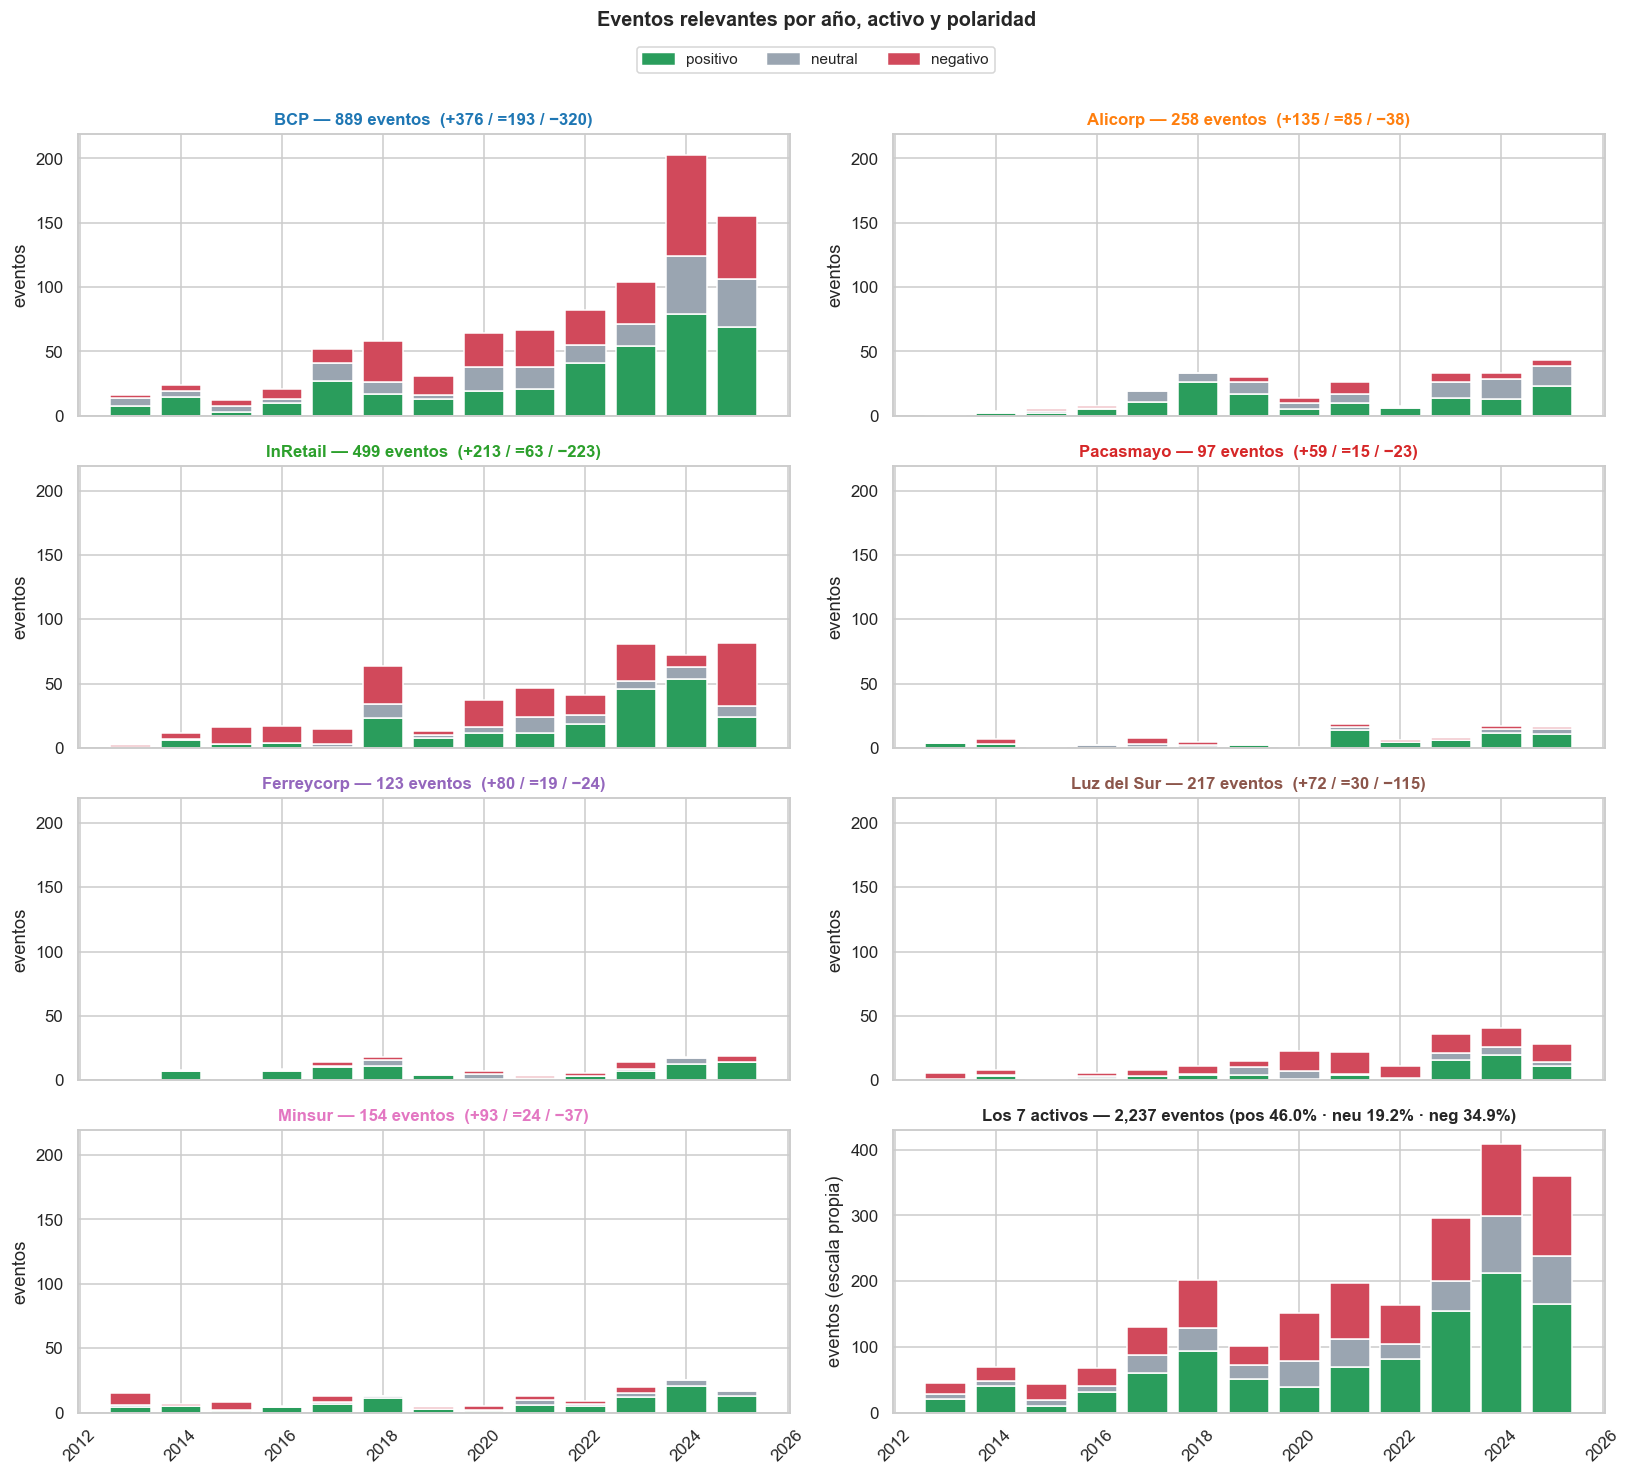

Eventos por activo y polaridad:


polaridad,positivo,neutral,negativo,total
ticker,,,,
CREDITC1,376,193,320,889
ALICORC1,135,85,38,258
INRETC1,213,63,223,499
CPACASC1,59,15,23,97
FERREYC1,80,19,24,123
LUSURC1,72,30,115,217
MINSURI1,93,24,37,154
TOTAL,1028,429,780,2237


In [4]:
ev = art[art['relevante']].copy()
ev['anio'] = ev['fecha'].dt.year
ev['polaridad'] = ev['polaridad'].fillna('neutral')
anios_rng = range(int(ev['anio'].min()), int(ev['anio'].max()) + 1)
POLS = ['positivo', 'neutral', 'negativo']

cnt = ev.groupby(['ticker', 'anio', 'polaridad']).size().unstack('polaridad').reindex(columns=POLS).fillna(0)
ymax = cnt.sum(axis=1).max() * 1.08

fig, axes = plt.subplots(4, 2, figsize=(15, 13), sharex=True)
axes = axes.flatten()
for ax, t in zip(axes, TICKERS):
    c = cnt.loc[t].reindex(anios_rng).fillna(0) if t in cnt.index.get_level_values(0) else None
    base = np.zeros(len(c))
    for p in POLS:
        ax.bar(c.index, c[p], bottom=base, color=COLOR_POL[p], label=p, width=0.8)
        base += c[p].values
    tot = ev[ev.ticker == t]
    ax.set_title(f'{NOMBRES[t]} — {len(tot)} eventos  (+{(tot.polaridad == "positivo").sum()} / '
                 f'={(tot.polaridad == "neutral").sum()} / −{(tot.polaridad == "negativo").sum()})',
                 fontweight='bold', color=COLOR_MAP[t])
    ax.set_ylim(0, ymax)
    ax.set_ylabel('eventos')

# último panel: total del universo
ax = axes[-1]
tot = ev.groupby(['anio', 'polaridad']).size().unstack().reindex(index=anios_rng, columns=POLS).fillna(0)
base = np.zeros(len(tot))
for p in POLS:
    ax.bar(tot.index, tot[p], bottom=base, color=COLOR_POL[p], width=0.8)
    base += tot[p].values
pp = ev['polaridad'].value_counts()
ax.set_title(f'Los 7 activos — {len(ev):,} eventos (pos {pp["positivo"] / len(ev):.1%} · '
             f'neu {pp["neutral"] / len(ev):.1%} · neg {pp["negativo"] / len(ev):.1%})',
             fontweight='bold')
ax.set_ylabel('eventos (escala propia)')
for ax in axes[-2:]:
    ax.tick_params(axis='x', labelbottom=True, rotation=45)
handles = [plt.Rectangle((0, 0), 1, 1, color=COLOR_POL[p]) for p in POLS]
fig.legend(handles, POLS, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.01), fontsize=10)
fig.suptitle('Eventos relevantes por año, activo y polaridad', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print('Eventos por activo y polaridad:')
t2 = ev.pivot_table(index='ticker', columns='polaridad', values='id', aggfunc='size').reindex(index=TICKERS, columns=POLS).fillna(0).astype(int)
t2['total'] = t2.sum(axis=1)
t2.loc['TOTAL'] = t2.sum()
t2

## 4. Correlación de la señal neta con el retorno por desfase (Figura 13)

Señal neta del día de un activo = eventos positivos − eventos negativos (en el panel, ya con el roll-forward de fines de semana al siguiente día hábil). Se mide la correlación de Spearman entre el **signo** de esa señal y el z-score del retorno del activo **k días hábiles después** de la fecha de la noticia, solo en días con señal no nula y con precio propio (sin precio arrastrado):

- **k = −1**: retorno del día ANTERIOR a la noticia (¿la prensa reporta lo que ya pasó?).
- **k = 0**: mismo día (indicio de look-ahead si fuera fuerte; la fecha de MediaCloud no tiene hora).
- **k = +1, +2**: días siguientes. Por el reloj del entorno (observación con datos hasta e−1, ejecución al cierre de e, retorno de e a e+1), **k = +2 es el horizonte que el agente puede operar**.

Barras: los 7 activos agregados, con IC 95% (transformación de Fisher). Puntos: cada activo por separado. Reproduce `scripts/timing_sentimiento_post_fix.py`.

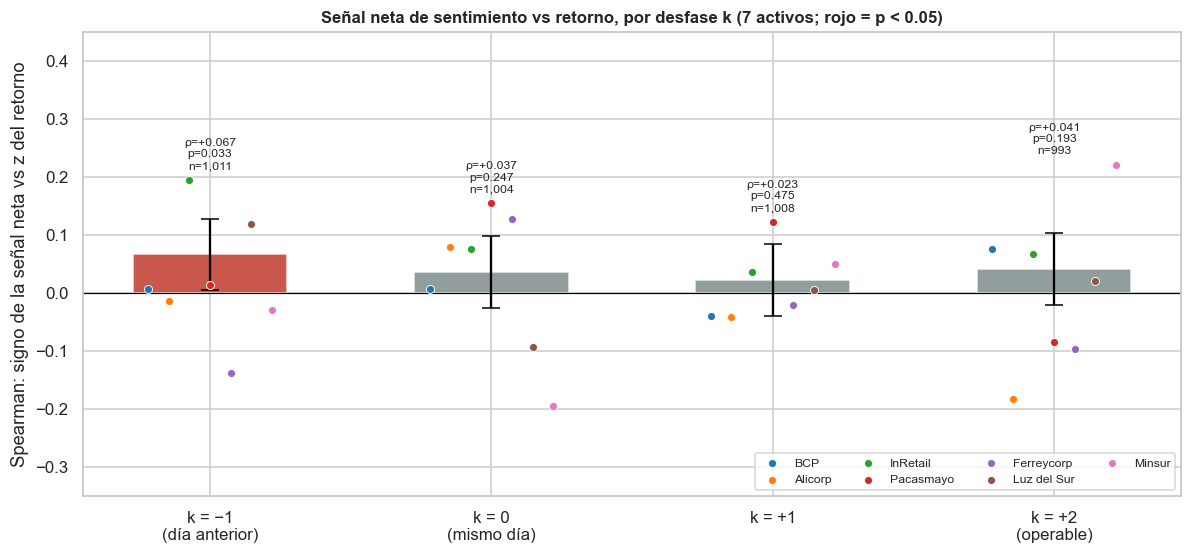

Agregado de los 7 activos:


,rho,p,n,acierto_signo,ic_bajo,ic_alto
k,,,,,,
-1,0.0671,0.0330,1011,0.5569,0.0054,0.1282
0,0.0366,0.2468,1004,0.5169,-0.0253,0.0982
1,0.0225,0.4754,1008,0.5198,-0.0393,0.0841
2,0.0413,0.1933,993,0.5307,-0.0209,0.1033


Por activo (rho; * = p < 0.05):


k,-1,0,1,2
ticker,,,,
CREDITC1,+0.007,+0.007,-0.039,+0.076
ALICORC1,-0.013,+0.080,-0.041,-0.183
INRETC1,+0.194*,+0.075,+0.037,+0.067
CPACASC1,+0.014,+0.154,+0.122,-0.085
FERREYC1,-0.138,+0.128,-0.020,-0.096
LUSURC1,+0.118,-0.093,+0.005,+0.021
MINSURI1,-0.030,-0.195,+0.050,+0.221*


In [5]:
p = panel.sort_values(['ticker', 'date']).copy()
p['neto'] = (p.n_alto_pos + p.n_resto_pos) - (p.n_alto_neg + p.n_resto_neg)
p['z'] = p.groupby('ticker')['ret_1d'].transform(lambda s: (s - s.mean()) / s.std())
KS = [-1, 0, 1, 2]

def corr_k(df, k):
    zz = df.groupby('ticker')['z'].shift(-k)
    st = df.groupby('ticker')['is_stale'].shift(-k)
    m = df['neto'].ne(0) & zz.notna() & (st == 0)
    rho, pv = stats.spearmanr(np.sign(df.loc[m, 'neto']), zz[m])
    acierto = (np.sign(df.loc[m, 'neto']) == np.sign(zz[m])).mean()
    return rho, pv, int(m.sum()), acierto

agg = pd.DataFrame([dict(zip(['rho', 'p', 'n', 'acierto_signo'], corr_k(p, k)), k=k) for k in KS]).set_index('k')
se = 1 / np.sqrt(agg['n'] - 3)
agg['ic_bajo'] = np.tanh(np.arctanh(agg['rho']) - 1.96 * se)
agg['ic_alto'] = np.tanh(np.arctanh(agg['rho']) + 1.96 * se)
por = pd.DataFrame([dict(ticker=t, k=k, rho=corr_k(p[p.ticker == t], k)[0],
                         p=corr_k(p[p.ticker == t], k)[1])
                    for t in TICKERS for k in KS])

fig, ax = plt.subplots(figsize=(11, 5.2))
x = np.arange(len(KS))
col = ['#c0392b' if pv < 0.05 else '#7f8c8d' for pv in agg['p']]
ax.bar(x, agg['rho'], color=col, width=0.55, alpha=0.85, zorder=2)
ax.errorbar(x, agg['rho'], yerr=[agg['rho'] - agg['ic_bajo'], agg['ic_alto'] - agg['rho']],
            fmt='none', ecolor='black', capsize=6, zorder=3)
desp = np.linspace(-0.22, 0.22, len(TICKERS))
for j, t in enumerate(TICKERS):
    s = por[por.ticker == t].set_index('k').reindex(KS)
    ax.scatter(x + desp[j], s['rho'], color=COLOR_MAP[t], s=28, zorder=4,
               edgecolor='white', linewidth=0.6, label=NOMBRES[t])
for xi, (k, r) in zip(x, agg.iterrows()):
    ax.text(xi, max(r['ic_alto'], por[por.k == k]['rho'].max()) + 0.02,
            f"ρ={r['rho']:+.3f}\np={r['p']:.3f}\nn={int(r['n']):,}", ha='center', fontsize=8)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(['k = −1\n(día anterior)', 'k = 0\n(mismo día)', 'k = +1', 'k = +2\n(operable)'])
ax.set_ylabel('Spearman: signo de la señal neta vs z del retorno')
ax.set_ylim(-0.35, 0.45)
ax.set_title('Señal neta de sentimiento vs retorno, por desfase k (7 activos; rojo = p < 0.05)',
             fontweight='bold')
ax.legend(fontsize=8, ncol=4, loc='lower right')
plt.tight_layout()
plt.show()

print('Agregado de los 7 activos:')
display(agg.round(4))
print('Por activo (rho; * = p < 0.05):')
por['celda'] = por.apply(lambda r: f"{r['rho']:+.3f}{'*' if r['p'] < 0.05 else ''}", axis=1)
por.pivot(index='ticker', columns='k', values='celda').reindex(TICKERS)

**Lectura.** La única asociación significativa en el agregado es con el retorno del día ANTERIOR a la noticia (k = −1): la prensa reporta el movimiento más de lo que lo anticipa (eco, coherente con D19). No hay asociación con el retorno del mismo día (sin indicio de look-ahead) ni con los horizontes operables (k = +1, +2). Son 4 desfases x 8 series con n chico por activo: es diagnóstico, no hallazgo; la prueba de valor del canal es la ablación de R8.